# Data Science Project 1 — Advanced EDA & Feature Engineering

**Intern Name:**Karan Kumar
**Batch:** 2026
**Organization:** DecodeLabs

## About the Dataset
This dataset contains e-commerce orders data with 1200 rows and 14 columns.
It includes information about products, prices, payment methods, order status and coupons.

## Objective
The goal of this project is to clean the raw dataset by:
- Handling missing values
- Detecting and neutralizing outliers
- Engineering new features
- Encoding categorical columns

In [1]:
## Step 1: Importing the important libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Step 2: Load and preview the dataset

In [2]:
#Load the dataset 
df=pd.read_excel("Dataset for Data Analytics.xlsx")

#shape of dataset
print(df.shape)

#Check column names
print(df.columns.tolist())

(1200, 14)
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']


In [3]:
#Preview first 10 rows of dataset and exploring the dataset with details
df.head(10)
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


## Step 3: Investigating missing values

In [4]:
#Find the missing values in from the given dataset
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In Step 3 there are 309 missing values out of 1200 rows dataset from the column "CouponCode". The reason might be that customer did not use any coupon while shopping or anyother

## Step 4: Hanlding missing values

In [5]:
#Handle the missing values 
df["CouponCode"]=df["CouponCode"].fillna("NoCoupon")

The values were missing form the "CouponCode" column so the were handled my writing "NoCoupon" in missing place

In [6]:
#Preview the dataset after handling missing values
print("Missing values after handling",df.isnull().sum())

Missing values after handling OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64


## Step 5: Perform Exploratory data analysis (EDA) on the given dataset

In [8]:
#Product sales
df["Product"].value_counts()

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

In [9]:
#PaymentMethod
df["PaymentMethod"].value_counts()

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

In [10]:
#ReferralSource
df["ReferralSource"].value_counts()

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

In [11]:
#OrderStatus
df["OrderStatus"].value_counts()

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

# Visulaize the outliers through histogram

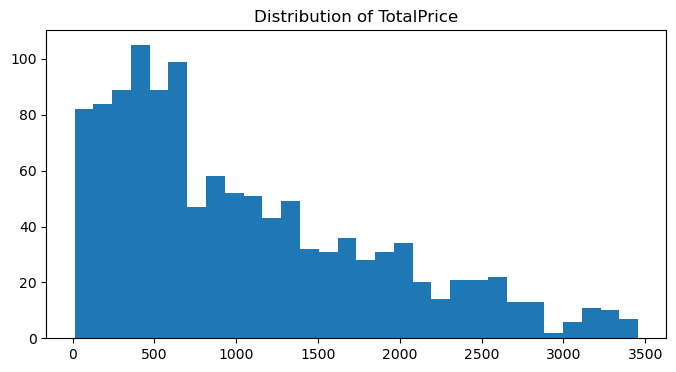

In [12]:
plt.figure(figsize=(8,4))
plt.hist(df["TotalPrice"], bins=30)
plt.title("Distribution of TotalPrice")
plt.show()

# Outliers Detection (Before Detection)

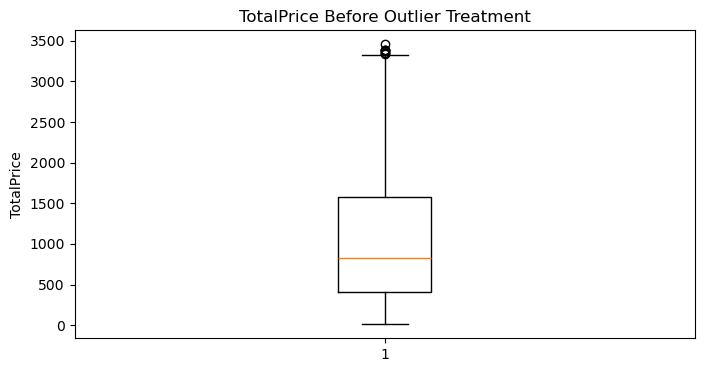

In [13]:
plt.figure(figsize=(8,4))
plt.boxplot(df["TotalPrice"])
plt.title("TotalPrice Before Outlier Treatment")
plt.ylabel("TotalPrice")
plt.show()

## Step 6: Outlier Detection using IQR Method
We use the Interquartile Range (IQR) method to detect 
outliers in numeric columns UnitPrice and TotalPrice.
Formula:
- Lower Bound = Q1 - 1.5 * IQR
- Upper Bound = Q3 + 1.5 * IQR
Any value outside these bounds is considered an outlier.

In [14]:
# Calculate Q1, Q3 and IQR
Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

# Calculate bounds
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Find outliers
outliers = df[
    (df["TotalPrice"] < lower) |
    (df["TotalPrice"] > upper)
]

# Display calculations
print("Total records:", len(df))
print("Q1 (25th percentile):", Q1)
print("Q3 (75th percentile):", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower)
print("Upper Bound:", upper)

print("\nNumber of Outliers Found:")
print(outliers.shape)

print("\nOutlier TotalPrice Values:")
print(outliers["TotalPrice"].tolist())

outliers[["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]]


Total records: 1200
Q1 (25th percentile): 410.52
Q3 (75th percentile): 1578.475
IQR: 1167.955
Lower Bound: -1341.4125
Upper Bound: 3330.4075

Number of Outliers Found:
(8, 14)

Outlier TotalPrice Values:
[3353.75, 3352.4, 3370.2, 3384.9, 3390.8, 3456.4, 3334.0, 3390.95]


,Quantity,UnitPrice,ItemsInCart,TotalPrice
107,5,670.75,8,3353.75
326,5,670.48,5,3352.40
328,5,674.04,7,3370.20
469,5,676.98,5,3384.90
632,5,678.16,7,3390.80
789,5,691.28,10,3456.40
1065,5,666.80,7,3334.00
1122,5,678.19,8,3390.95


# Visualize the outliers before capping

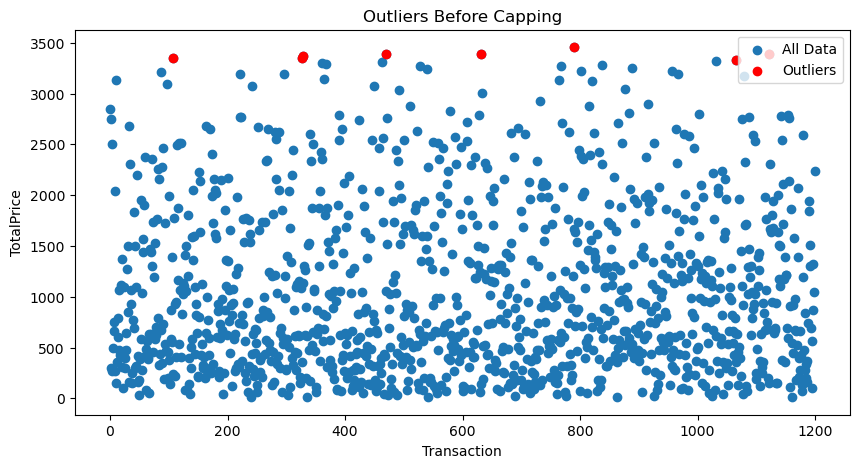

In [16]:
plt.figure(figsize=(10,5))

plt.scatter(df.index,
            df["TotalPrice"],
            label="All Data")

plt.scatter(outliers.index,
            outliers["TotalPrice"],
            color="red",
            label="Outliers")

plt.title("Outliers Before Capping")
plt.xlabel("Transaction")
plt.ylabel("TotalPrice")
plt.legend()

plt.show()

## Step 7: Neutralizing Outliers using Capping (Winsorization)
Instead of deleting outlier rows we cap them at the 
IQR boundary using numpy.clip().
This preserves our row count of 1200 rows and 
prevents data loss while neutralizing extreme values.

In [17]:
# Apply capping
df["TotalPrice"] = df["TotalPrice"].clip(lower=lower, upper=upper)

print("Capping applied successfully.")

Capping applied successfully.


In [18]:
#Checking the maxumum values after capping 
print(df["TotalPrice"].max())


3330.4075


In [19]:
#Verification of Outliers that if they remain 0
outliers_after = df[
    (df["TotalPrice"] < lower) |
    (df["TotalPrice"] > upper)
]

print(outliers_after.shape)

(0, 14)


# Visualize outliers after capping

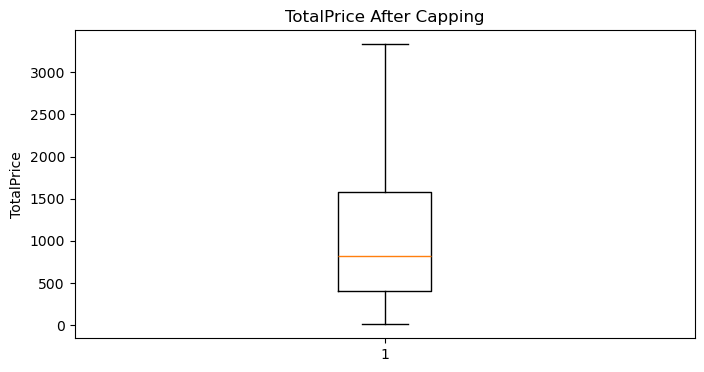

In [20]:
plt.figure(figsize=(8,4))
plt.boxplot(df["TotalPrice"])
plt.title("TotalPrice After Capping")
plt.ylabel("TotalPrice")
plt.show()

## Step 8: Feature Engineering
We create 3 new features from existing columns to 
provide more useful information for machine learning models.

- RevenuePerItem: Average revenue earned per single item
- HasCoupon: Whether customer used a coupon or not (1 or 0)
- CartFillRate: How much of the cart was actually ordered


In [21]:
# Feature 1: Revenue per item
df['RevenuePerItem'] = df['TotalPrice'] / df['Quantity']

# Feature 2: Has coupon or not
df['HasCoupon'] = df['CouponCode'].apply(
    lambda x: 0 if x == 'NO_COUPON' else 1)

# Feature 3: Cart fill rate
df['CartFillRate'] = df['Quantity'] / df['ItemsInCart']

# Preview new features
print("New Features Successfully Created:")
df[['RevenuePerItem', 'HasCoupon', 'CartFillRate']].head()

New Features Successfully Created:


,RevenuePerItem,HasCoupon,CartFillRate
0,570.62,1,0.714286
1,151.35,1,0.666667
2,550.68,1,0.625000
3,273.19,1,0.200000
4,626.01,1,0.500000


In [22]:
df.head(10)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,RevenuePerItem,HasCoupon,CartFillRate
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,570.62,1,0.714286
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,151.35,1,0.666667
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,550.68,1,0.625000
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,273.19,1,0.200000
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,626.01,1,0.500000
5,ORD200005,2023-10-23,C37249,Phone,2,245.86,934 Main St,Credit Card,Shipped,TRK72976927,4,SAVE10,Instagram,491.72,245.86,1,0.500000
6,ORD200006,2025-06-17,C83492,Laptop,1,664.42,986 Main St,Gift Card,Returned,TRK96417362,6,SAVE10,Facebook,664.42,664.42,1,0.166667
7,ORD200007,2023-05-12,C41460,Monitor,5,149.55,706 Main St,Cash,Shipped,TRK78809193,9,FREESHIP,Facebook,747.75,149.55,1,0.555556
8,ORD200008,2025-04-02,C26817,Phone,2,134.28,904 Main St,Gift Card,Cancelled,TRK61042692,2,NoCoupon,Email,268.56,134.28,1,1.000000
9,ORD200009,2023-11-21,C31946,Desk,4,509.38,102 Main St,Credit Card,Shipped,TRK33478363,6,SAVE10,Google,2037.52,509.38,1,0.666667


In [23]:
df.to_csv("cleaned_dataset.csv", index=False)